In [ ]:
# 1 import pakages 
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor)
from xgboost import XGBRegressor

from sklearn.preprocessing import LabelEncoder, MinMaxScaler 
from sklearn.model_selection import train_test_split

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# System & warnings
import warnings 
warnings.filterwarnings('ignore')

# Set visual style


In [931]:
sns.set(style="whitegrid") 
plt.rcParams["figure.figsize"] = (10, 6)

In [932]:
# 2. Load Dataset
df = pd.read_csv("Smart_Farming_Crop_Yield_2024.csv")
print(df.head())
#print(df.columns)

    farm_id       region crop_type  soil_moisture_%  soil_pH  temperature_C  \
0  FARM0001  North India     Wheat            35.95     5.99          17.79   
1  FARM0002    South USA   Soybean            19.74     7.24          30.18   
2  FARM0003    South USA     Wheat            29.32     7.16          27.37   
3  FARM0004  Central USA     Maize            17.33     6.03          33.73   
4  FARM0005  Central USA    Cotton            19.37     5.92          33.86   

   rainfall_mm  humidity_%  sunlight_hours irrigation_type  ... sowing_date  \
0        75.62       77.03            7.27             NaN  ...  2024-01-08   
1        89.91       61.13            5.67       Sprinkler  ...  2024-02-04   
2       265.43       68.87            8.23            Drip  ...  2024-02-03   
3       212.01       70.46            5.03       Sprinkler  ...  2024-02-21   
4       269.09       55.73            7.93             NaN  ...  2024-02-05   

   harvest_date total_days yield_kg_per_hectare  s

In [933]:
#  Filter out maize only datasets
df_maize = df[df['crop_type'] == 'Maize'] 
print("Maize records:", df_maize.shape[0])  
print(df_maize.head(3))

Maize records: 111
     farm_id       region crop_type  soil_moisture_%  soil_pH  temperature_C  \
3   FARM0004  Central USA     Maize            17.33     6.03          33.73   
7   FARM0008  East Africa     Maize            27.10     5.72          22.26   
12  FARM0013    South USA     Maize            42.43     7.07          20.70   

    rainfall_mm  humidity_%  sunlight_hours irrigation_type  ... sowing_date  \
3        212.01       70.46            5.03       Sprinkler  ...  2024-02-21   
7        296.33       80.34            5.44       Sprinkler  ...  2024-01-24   
12       224.15       76.53            8.70             NaN  ...  2024-01-02   

    harvest_date total_days yield_kg_per_hectare  sensor_id   timestamp  \
3     2024-07-04        134              4227.80   SENS0004  2024-05-14   
7     2024-05-24        121              5264.09   SENS0008  2024-04-30   
12    2024-05-08        127              4942.95   SENS0013  2024-01-17   

     latitude  longitude  NDVI_index  

In [934]:
# Remove irrelevant features
irrelevant_features_to_drop = ['farm_id', 'crop_type', 'sensor_id', 'timestamp']
df_maize = df_maize.drop(columns=irrelevant_features_to_drop, errors='ignore')

In [935]:
# 3. Initial Data Exploration 
print(df_maize)
print(df_maize.columns) 
print(df_maize.info())

          region  soil_moisture_%  soil_pH  temperature_C  rainfall_mm  \
3    Central USA            17.33     6.03          33.73       212.01   
7    East Africa            27.10     5.72          22.26       296.33   
12     South USA            42.43     7.07          20.70       224.15   
14   South India            23.85     6.84          21.00       129.04   
15   Central USA            15.52     7.17          29.07       202.92   
..           ...              ...      ...            ...          ...   
472  Central USA            37.23     5.79          30.96       118.41   
473  East Africa            29.30     6.71          32.93        92.69   
478  Central USA            26.91     6.03          15.04       207.79   
479    South USA            10.31     6.36          18.95       182.27   
491  North India            32.14     7.44          21.49       286.61   

     humidity_%  sunlight_hours irrigation_type fertilizer_type  \
3         70.46            5.03       Sprink

In [936]:
# target variable definition 
target_variable = 'yield_kg_per_hectare'
X = df.drop(columns=[target_variable], errors='ignore')
y = df[target_variable]
print(df[target_variable].describe())

count     500.00000
mean     4032.92694
std      1174.43304
min      2023.56000
25%      2994.82000
50%      4071.69000
75%      5062.11000
max      5998.29000
Name: yield_kg_per_hectare, dtype: float64


In [937]:
# Numeric and categorical features
numeric_features = X.select_dtypes(include=[np.int64, np.float64]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [938]:
# Checking for missing values and summarizing the statistics of the dataset 
missing_values = df.isnull().sum()
summary_statistics = df.describe(include='all')

In [939]:
# Basic statistical summary of the dataset 
summary = df.describe(include='all').transpose()

In [940]:
# Displaying the missing values and summary statistics 
print(missing_values)
print(summary_statistics)

farm_id                   0
region                    0
crop_type                 0
soil_moisture_%           0
soil_pH                   0
temperature_C             0
rainfall_mm               0
humidity_%                0
sunlight_hours            0
irrigation_type         150
fertilizer_type           0
pesticide_usage_ml        0
sowing_date               0
harvest_date              0
total_days                0
yield_kg_per_hectare      0
sensor_id                 0
timestamp                 0
latitude                  0
longitude                 0
NDVI_index                0
crop_disease_status     130
dtype: int64
         farm_id       region crop_type  soil_moisture_%     soil_pH  \
count        500          500       500       500.000000  500.000000   
unique       500            5         5              NaN         NaN   
top     FARM0001  Central USA     Maize              NaN         NaN   
freq           1          109       111              NaN         NaN   
mean       

In [941]:
# Check for unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
unique_values = {col: df[col].unique()[:5] for col in categorical_cols} # Show t

# Check for class balance in key categorical features
category_distributions = df[categorical_cols].nunique().to_frame(name='Unique_Values')
summary, unique_values, category_distributions

(                      count unique          top freq        mean         std  \
 farm_id                 500    500     FARM0001    1         NaN         NaN   
 region                  500      5  Central USA  109         NaN         NaN   
 crop_type               500      5        Maize  111         NaN         NaN   
 soil_moisture_%       500.0    NaN          NaN  NaN    26.75014   10.150053   
 soil_pH               500.0    NaN          NaN  NaN     6.52398    0.585558   
 temperature_C         500.0    NaN          NaN  NaN    24.67574    5.348899   
 rainfall_mm           500.0    NaN          NaN  NaN   181.68574   72.293091   
 humidity_%            500.0    NaN          NaN  NaN    65.19446   14.642849   
 sunlight_hours        500.0    NaN          NaN  NaN     7.03014     1.69167   
 irrigation_type         350      3    Sprinkler  121         NaN         NaN   
 fertilizer_type         500      3    Inorganic  167         NaN         NaN   
 pesticide_usage_ml    500.0

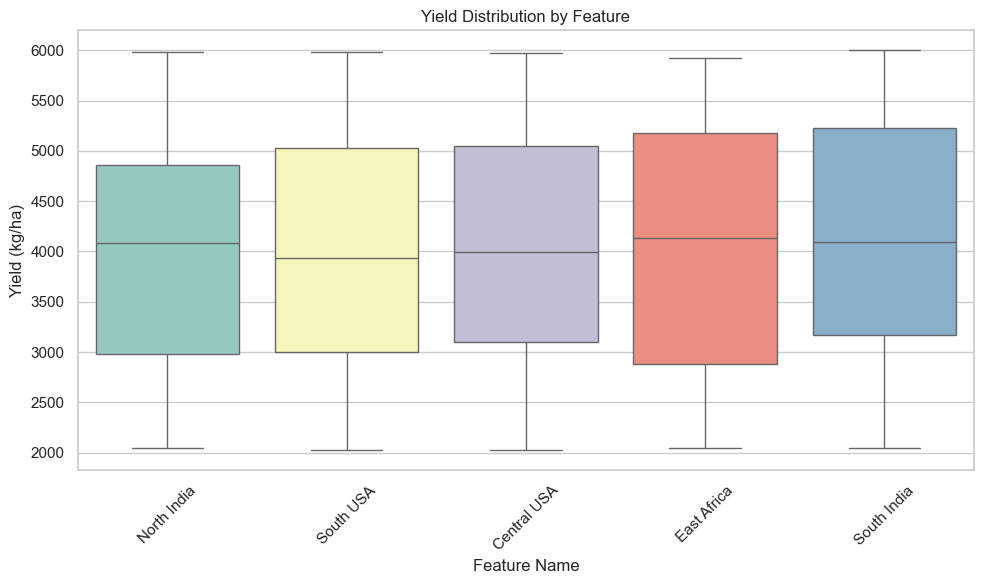

In [942]:
# Distribution of crop yield by feature_name

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='region',              # replace with actual feature column
    y='yield_kg_per_hectare',      # replace with actual yield column if needed
    data=df,
    palette='Set3'
)

plt.title('Yield Distribution by Feature')
plt.xlabel('Feature Name')
plt.ylabel('Yield (kg/ha)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

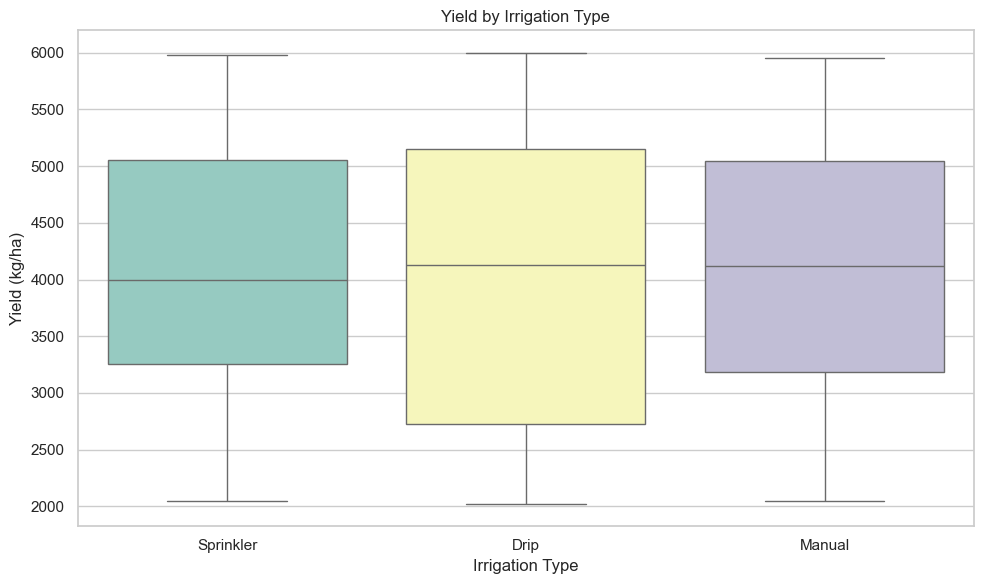

In [943]:
# 2. Yield distribution by irrigation type
plt.figure(figsize=(10, 6))
sns.boxplot(x='irrigation_type', y='yield_kg_per_hectare', data=df, palette='Set3') 
plt.title('Yield by Irrigation Type')
plt.xlabel('Irrigation Type')
plt.ylabel('Yield (kg/ha)')
plt.tight_layout()
plt.show()

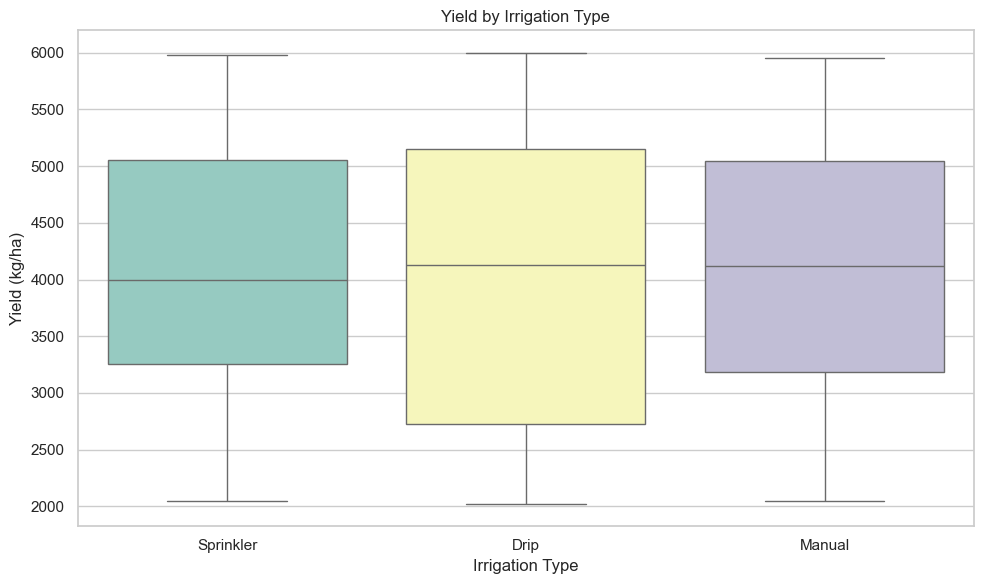

In [944]:
# 2. Yield distribution by irrigation type
plt.figure(figsize=(10, 6))
sns.boxplot(x='irrigation_type', y='yield_kg_per_hectare', data=df, palette='Set3')
plt.title('Yield by Irrigation Type')
plt.xlabel('Irrigation Type')
plt.ylabel('Yield (kg/ha)')
plt.tight_layout()
plt.show()

In [945]:
# 🔥 Heatmap Korelasi untuk fitur numerik
# Pilih hanya kolom numerik
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Hitung korelasi
correlation_matrix = numerical_df.corr()

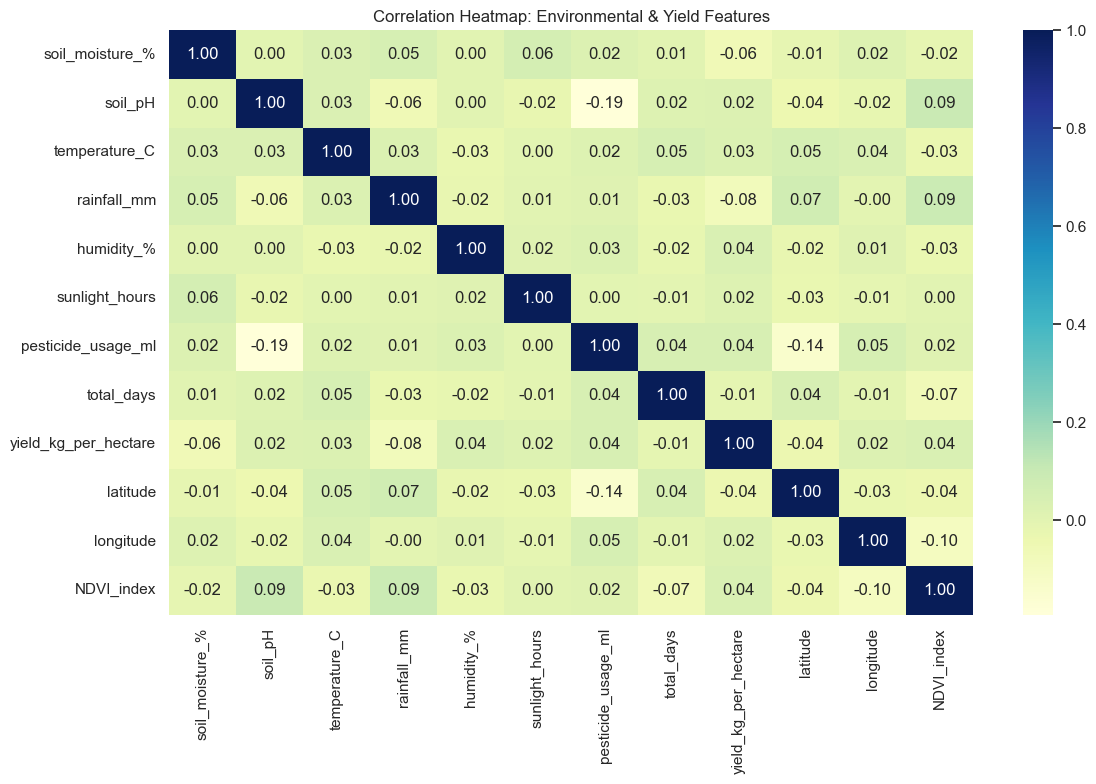

In [946]:
# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0) 
plt.title("Correlation Heatmap: Environmental & Yield Features") 
plt.tight_layout()
plt.show()

In [947]:
# Scatter plot latitude dan longitude
fig = px.scatter_geo(df, lat='latitude', lon='longitude', color='crop_type',
                     size='yield_kg_per_hectare', hover_name='region',
                     color_continuous_scale='Viridis', title="Spatial Distribution of Crop Yield")

fig.update_geos(showcoastlines=True, coastlinecolor="Black", projection_type="orthographic")
fig.show()


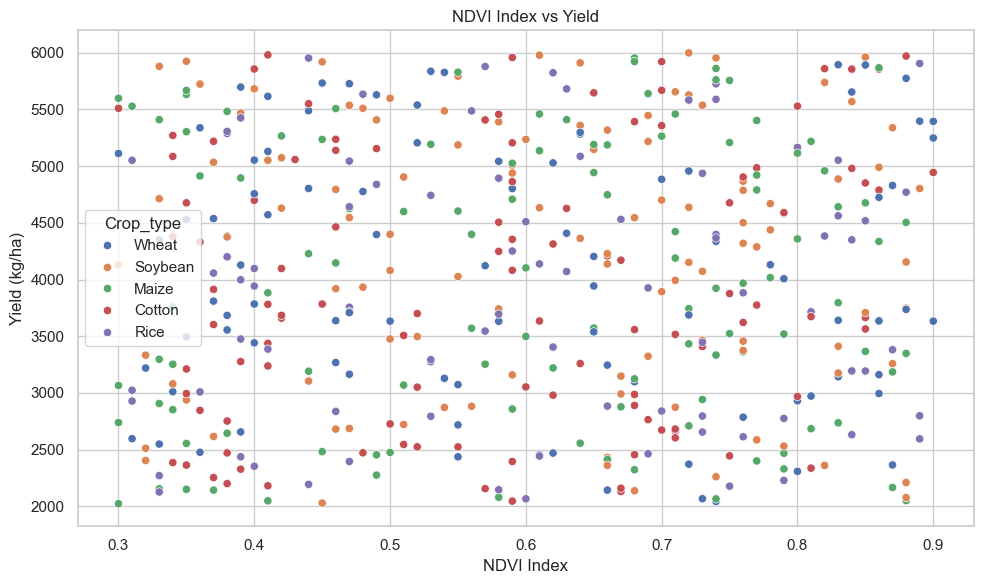

In [948]:
# Membuat scatter plot untuk melihat hubungan NDVI vs Yield 
plt.figure(figsize=(10, 6))
sns.scatterplot(x='NDVI_index', y='yield_kg_per_hectare', data=df, hue='crop_type')
plt.title('NDVI Index vs Yield')
plt.xlabel('NDVI Index')
plt.ylabel('Yield (kg/ha)')
plt.legend(title='Crop_type')
plt.tight_layout()
plt.show()

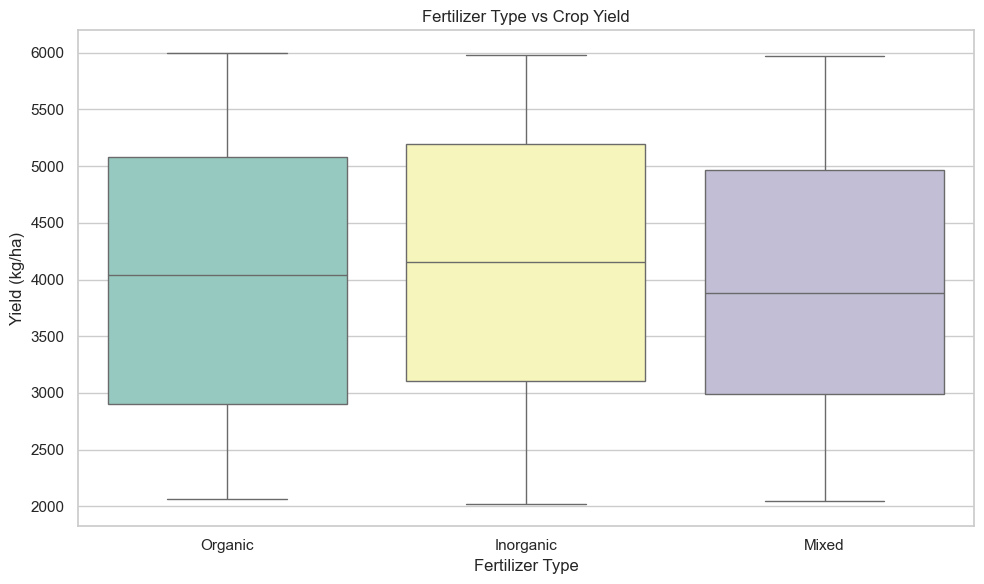

In [949]:
# Fertilizer Type vs Yield
plt.figure(figsize=(10, 6))
sns.boxplot(x='fertilizer_type', y='yield_kg_per_hectare', data=df,palette='Set3') 
plt.title('Fertilizer Type vs Crop Yield')
plt.xlabel('Fertilizer Type')
plt.ylabel('Yield (kg/ha)')
plt.tight_layout()
plt.show()

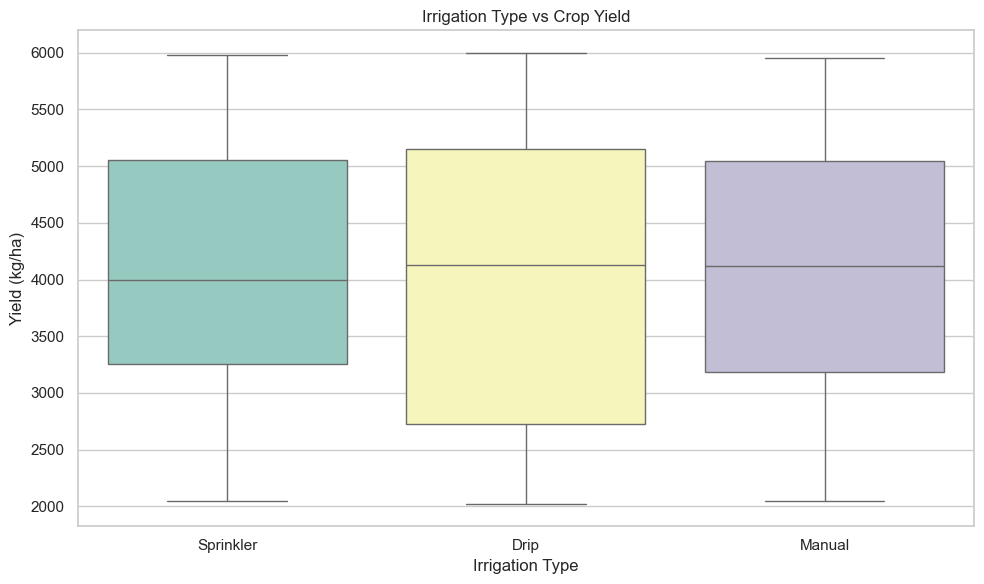

In [950]:
# Irrigation_Type vs Yield
plt.figure(figsize=(10, 6))
sns.boxplot(x='irrigation_type', y='yield_kg_per_hectare', data=df,palette="Set3")
plt.title('Irrigation Type vs Crop Yield')
plt.xlabel('Irrigation Type')
plt.ylabel('Yield (kg/ha)')
plt.tight_layout()
plt.show()

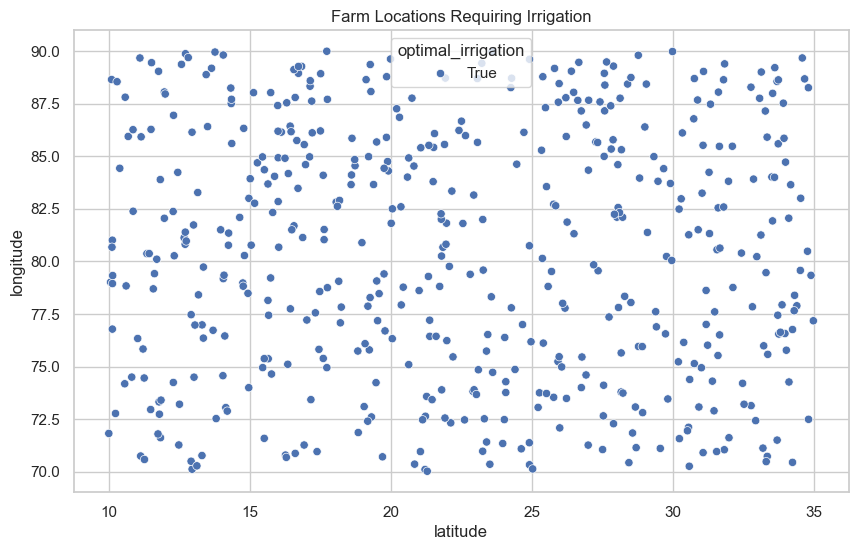

In [951]:
#Farm Location Analysis: Identifying Farms Needing Irrigation
df['optimal_irrigation'] = (df['soil_moisture_%'] < 50) & (df['rainfall_mm'] < 1000)
irrigation_needed = df[df['optimal_irrigation'] == True]

# Visualisation of farms needing irrigation
sns.scatterplot(x='latitude', y='longitude', data=irrigation_needed, hue='optimal_irrigation') 
plt.title('Farm Locations Requiring Irrigation')
plt.show() 

In [952]:
df['harvest_date'] = pd.to_datetime(df['harvest_date'])

In [953]:
df_monthly = df.resample('M', on='harvest_date')['yield_kg_per_hectare'].mean()

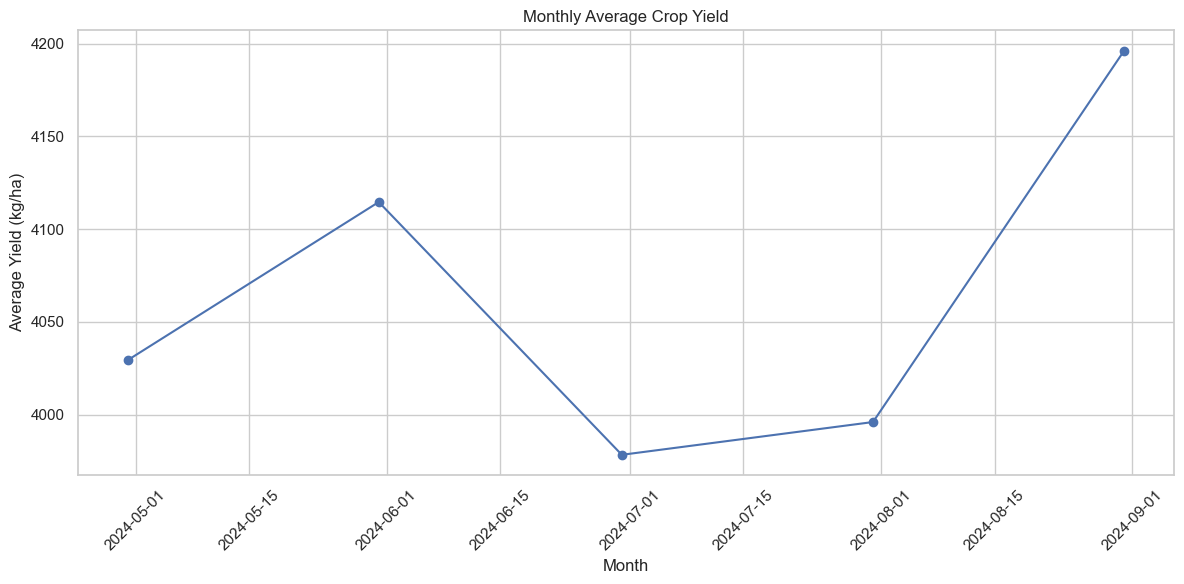

In [954]:
# 3. Visualisation of time trends
plt.figure(figsize=(12,6))
plt.plot(df_monthly.index, df_monthly.values, marker='o') 
plt.title('Monthly Average Crop Yield') 
plt.xlabel('Month')
plt.ylabel('Average Yield (kg/ha)') 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [955]:
# Data Preprocessing
# 1. Convert date columns to datetime format 
df['sowing_date'] = pd.to_datetime(df['sowing_date']) 
df['harvest_date'] = pd.to_datetime(df['harvest_date']) 
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [956]:
# 2. Feature Engineering: Calculate growth_duration (days between sowing and harv 
df['growth_duration'] = (df['harvest_date'] - df['sowing_date']).dt.days

In [957]:
# 3. Encode categorical variables using LabelEncoder or One-Hot Encoding 
from sklearn.preprocessing import LabelEncoder

# Label Encoding for categorical variables
label_encoder = LabelEncoder()
df['crop_type'] = label_encoder.fit_transform(df['crop_type']) 
df['irrigation_type'] = label_encoder.fit_transform(df['irrigation_type']) 
df['fertilizer_type'] = label_encoder.fit_transform(df['fertilizer_type']) 
df['crop_disease_status'] = label_encoder.fit_transform(df['crop_disease_status'])

In [958]:
# 4. Scale numerical features using MinMaxScaler 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numerical_cols = ['soil_moisture_%', 'rainfall_mm', 'NDVI_index', 'growth_duration'] 
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [959]:
# 5. Remove outliers based on IQR for yield_kg_per_hectare 
Q1 = df['yield_kg_per_hectare'].quantile(0.25)
Q3 = df['yield_kg_per_hectare'].quantile(0.75)
IQR = Q3 - Q1
# Define the outlier condition
outlier_condition = (df['yield_kg_per_hectare'] < (Q1 - 1.5 * IQR)) | (df['yield_kg_per_hectare'] > (Q3 + 1.5 * IQR))
# Remove the outliers
df_cleaned = df[~outlier_condition]

In [960]:
# 
cols_to_drop = [
    'farm_id', 'sensor_id',                     # ID — tidak perlu
    'sowing_date', 'harvest_date', 'timestamp', # tanggal
    'region',                                   # kategorikal (jika belum di-encode)
    'latitude', 'longitude'                     # latitude & longitude boleh dipakai kalau mau spasial => jika tidak, bisa di
]

In [961]:
# Remove the columns from the cleaned dataset
df_model = df_cleaned.drop(columns=cols_to_drop)

In [962]:
X = df_model.drop('yield_kg_per_hectare', axis=1) 
y = df_model['yield_kg_per_hectare']

In [963]:
X = X.select_dtypes(include=['int64', 'float64'])

In [964]:
# 5. Split data
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [965]:
# 6. Fit Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr_model = LinearRegression() 
lr_model.fit(X_train, y_train) 
y_pred_lr = lr_model.predict(X_test)

In [966]:
# 7. Evaluation of Linear Regression
print("Linear Regression Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}") 
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.2f}") 
print(f"R2 Score: {r2_score(y_test, y_pred_lr):.2f}")

Linear Regression Performance:
MAE: 1064.81
MSE: 1453215.20
R2 Score: -0.05


In [967]:
# Initialisation model Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [968]:
# Evaluation of Random Forest Regressor
print("Random Forest Regressor Performance: ") 
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf)}") 
print(f"MSE: {mean_squared_error(y_test, y_pred_rf)}") 
print(f"R2 Score: {r2_score(y_test, y_pred_rf)}")

Random Forest Regressor Performance: 
MAE: 1050.054389
MSE: 1423103.2500058445
R2 Score: -0.030441753276314376


In [969]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [970]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [971]:
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Regressor Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb)}") 
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb)}") 
print(f"R2 Score: {r2_score(y_test, y_pred_xgb)}")

XGBoost Regressor Performance:
MAE: 1043.6669036132814
MSE: 1664104.7334273881
R2 Score: -0.20494630248458012


In [972]:
y_mean = y_train.mean()
baseline_preds = np.full_like(y_test, fill_value=y_mean) 
print("Baseline MAE:", mean_absolute_error(y_test, baseline_preds)) 
print("Baseline R2:", r2_score(y_test, baseline_preds))

Baseline MAE: 1051.4103
Baseline R2: -0.0004255782905853156


In [973]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42),
                            X, y, cv=5, scoring='r2', n_jobs=-1
)
print("RF CV R2 Scores:", cv_scores) 
print("Mean RF CV R2:", cv_scores.mean())

RF CV R2 Scores: [-0.12379416 -0.06008367 -0.04992333 -0.08074766 -0.15981025]
Mean RF CV R2: -0.09487181332763969


In [974]:
from sklearn.model_selection import GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20], 
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf, cv=3, scoring='r2', n_jobs=-1
)

grid_rf.fit(X_train, y_train)
print("Best RF params:", grid_rf.best_params_) 
print("Best RF R2:", grid_rf.best_score_)

Best RF params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}
Best RF R2: -0.005014913867850764


In [975]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [976]:
from sklearn.model_selection import RandomizedSearchCV 
param_dist_xgb = {
   'n_estimators': [100, 100],
    'max_depth': [3, 6, 9], 
    'learning_rate': [0.01, 0.1, 0.2], 
    'subsample': [0.6, 0.8, 1.0]
}

rand_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_dist_xgb, n_iter=20, cv=3, scoring='r2', n_jobs=-1, random_state=42
)

rand_xgb.fit(X_train, y_train)
print("Best XGB params:", rand_xgb.best_params_) 
print("Best XGB R2:", rand_xgb.best_score_)

Best XGB params: {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.01}
Best XGB R2: 0.008472864333904187


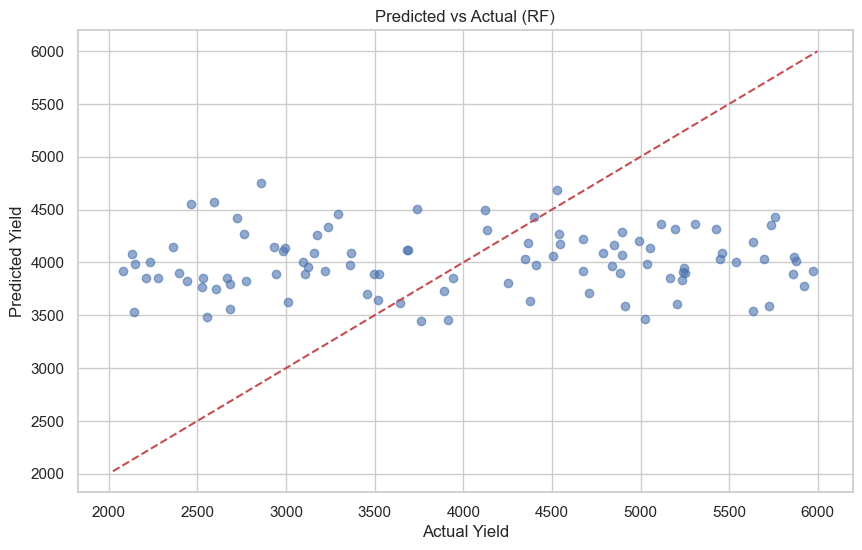

In [977]:
plt.scatter(y_test, y_pred_rf, alpha=0.6) 
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') 
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Predicted vs Actual (RF)")
plt.show()

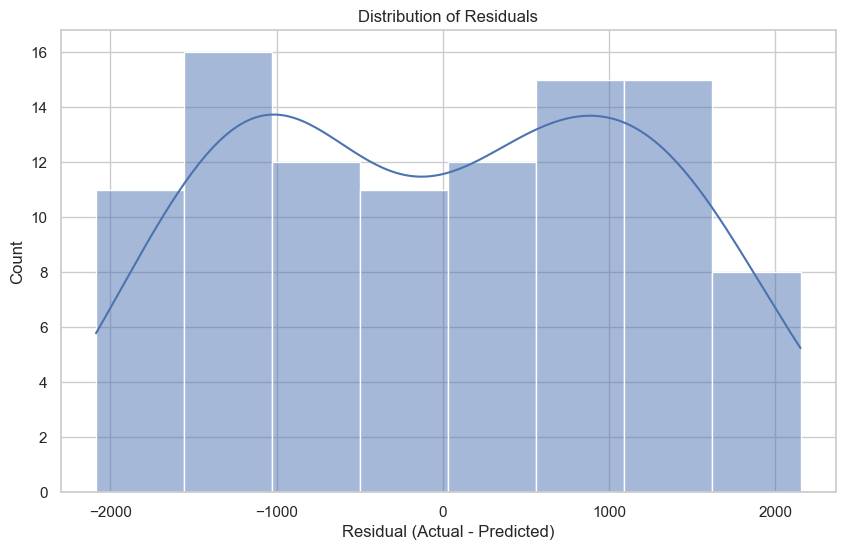

In [978]:
residuals = y_test - y_pred_rf 
sns.histplot(residuals, kde=True) 
plt.title("Distribution of Residuals") 
plt.xlabel("Residual (Actual - Predicted)") 
plt.show()

In [979]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20], 
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid=params, cv=3) 
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

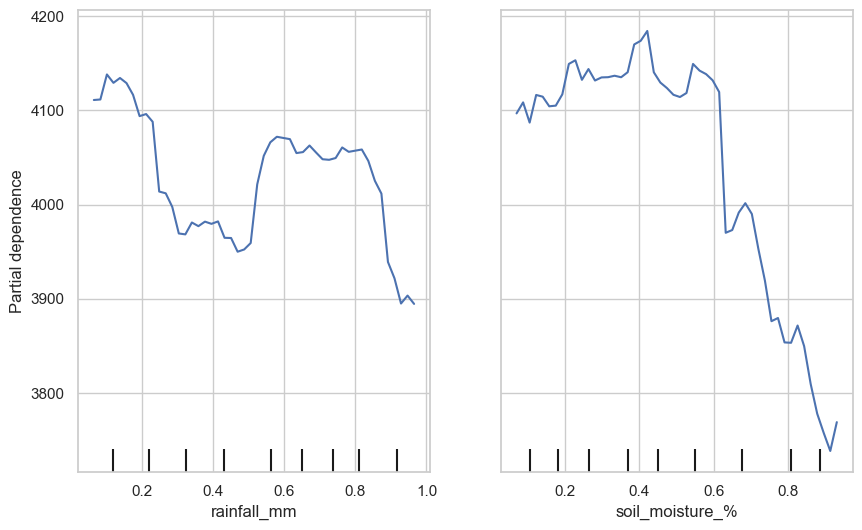

In [980]:
from sklearn.inspection import PartialDependenceDisplay
PartialDependenceDisplay.from_estimator(
    best_model,
    X_train,
    features=['rainfall_mm', 'soil_moisture_%'], 
    kind='average',
    grid_resolution=50
)

plt.show()

In [175]:
def maize_recommendation(rainfall,
                         soil_pH,
                         temperature,
                         humidity):

    recommendations = []

    if rainfall < 500:
        recommendations.append(
            "Use supplementary irrigation"
        )

    if soil_pH < 5.5:
        recommendations.append(
            "Apply lime to reduce acidity"
        )

    if temperature > 35:
        recommendations.append(
            "Use drought-tolerant maize varieties"
        )

    if humidity > 85:
        recommendations.append(
            "Monitor fungal disease risk"
        )

    print(recommendations)